In [20]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io

/Users/jukesliu/micromamba/envs/autoterm/lib/python3.9/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [19]:
def read_mat_data(filepath):
    rd = scipy.io.loadmat(filepath) # load the mat file
    PDATA = rd['PDATA']
    TWT = rd['TWT']
    
    return PDATA, TWT

# Simulate uncertainties in SWE

In [ ]:
# gather TWT_err using Uqtuiavik data!!!

In [23]:
# gather TWT_err using an approx. # of pixels in radargram
filespath = '/Users/jukesliu/Documents/POSTDOC/snow-radar/ReynoldsMountain/ProcessedApril2025/'
[PDATA, TWT] = read_mat_data(filespath+'pdriftzigzag_8_PDATA.mat')
halfidx = PDATA.shape[0]
TWT = TWT[0][halfidx:]
np.diff(TWT) 

array([1.14186605e-11, 1.14186605e-11, 1.14186605e-11, ...,
       1.14186605e-11, 1.14186605e-11, 1.14186605e-11])

In [58]:
SWE_err_lidar = []
SWE_err_TWT = []
N = 5000 # number of MC interations
rho_s = 370/1000 # snow density
f=10e9; T = -10; # E_snowdry

for n in range(0,N):
    # lidar uncertainty:
    lidar_std = 0.1 # 10 cm / 0.1 m std
    lidar_depth_err = np.random.normal(loc=0.0, scale=lidar_std) 
    SWE_val = rho_s*lidar_depth_err
    SWE_err_lidar.append(SWE_val)

    # TWT uncertainty
    TWT_std = np.diff(TWT)[0]*15
    TWT_err = np.random.normal(loc=0.0, scale=TWT_std) # TWT, 15 pixels
    rho = rho_s/1000 # change units to [g/cc]
    e_r = 1+1.7*rho+0.7*rho**2
    e_ice = 1.59e6*((1/f)+1.23e-14*np.sqrt(f))*np.exp(0.036*T) # imaginary part of dielectric constant of ice, From Tuiri, 1984
    e_i = (0.52*rho+0.62*rho**2)*e_ice # imaginary part of diel const of dry snow
    e_s = e_r-e_i*1j # complex dielectric constant of dry snow
    v=3e8/np.sqrt(np.real(e_s))
    SD = v*2*TWT_err # snow depth error from velocity and TWT error
    SWE_val = rho_s*SD
    SWE_err_TWT.append(SWE_val)
    
print('lidar depth std.:',lidar_std)  
print('TWT std.:',TWT_std)
print('snow depth std.:',SD)

lidar depth std.: 0.1
TWT std.: 1.7127990722656253e-10
snow depth std.: 0.014318854011172442


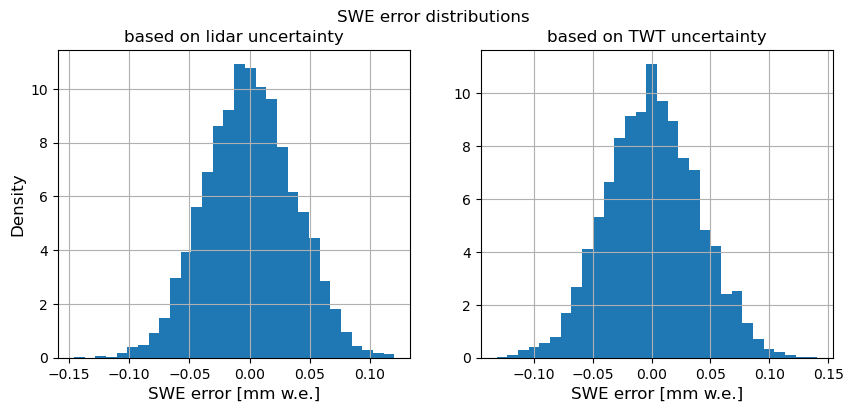

In [60]:
fs=12
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(10,4))
ax1.hist(SWE_err_lidar, bins=30, density=True)
ax2.hist(SWE_err_TWT, bins=30, density=True)
for ax in (ax1, ax2):
    ax.set_xlabel('SWE error [mm w.e.]', fontsize=fs)
    # ax.set_xlim(-150,150); ax.set_ylim(0,0.015)
    ax.grid()
ax1.set_ylabel('Density',fontsize=fs)
ax1.set_title('based on lidar uncertainty', fontsize=fs)
ax2.set_title('based on TWT uncertainty', fontsize=fs)
plt.suptitle('SWE error distributions', fontsize=fs)
plt.show()